In [ ]:
import pandas as pd
import numpy as np
import zipfile
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error
import seaborn as sns
from scipy.stats import skew
from catboost import CatBoostRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import make_scorer
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PowerTransformer
from scipy import stats
from sklearn.metrics import r2_score
import lightgbm as lgb
from sklearn.feature_selection import SelectKBest, f_regression
from itertools import combinations

### DATA LOADING AND PREPROCESSING

In [213]:
train_df=pd.read_csv(r"C:\Users\Hemant Pathak\Downloads\e25764c65bca11f0\dataset\train.csv")
test_df=pd.read_csv(r"C:\Users\Hemant Pathak\Downloads\e25764c65bca11f0\dataset\test.csv")
sample_solution_df=pd.read_csv(r"C:\Users\Hemant Pathak\Downloads\e25764c65bca11f0\dataset\sample_solution.csv")

In [165]:
# train_df.head()
test_df.describe().info()

<class 'pandas.core.frame.DataFrame'>
Index: 8 entries, count to max
Data columns (total 56 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     8 non-null      float64
 1   Component1_fraction    8 non-null      float64
 2   Component2_fraction    8 non-null      float64
 3   Component3_fraction    8 non-null      float64
 4   Component4_fraction    8 non-null      float64
 5   Component5_fraction    8 non-null      float64
 6   Component1_Property1   8 non-null      float64
 7   Component2_Property1   8 non-null      float64
 8   Component3_Property1   8 non-null      float64
 9   Component4_Property1   8 non-null      float64
 10  Component5_Property1   8 non-null      float64
 11  Component1_Property2   8 non-null      float64
 12  Component2_Property2   8 non-null      float64
 13  Component3_Property2   8 non-null      float64
 14  Component4_Property2   8 non-null      float64
 15  Component

In [298]:
X_first_prop=train_df.iloc[:,:10]
y_first_prop=train_df[['BlendProperty1']]

In [16]:
y_first_prop.shape
X_first_prop.shape

(2000, 10)

<Axes: ylabel='Count'>

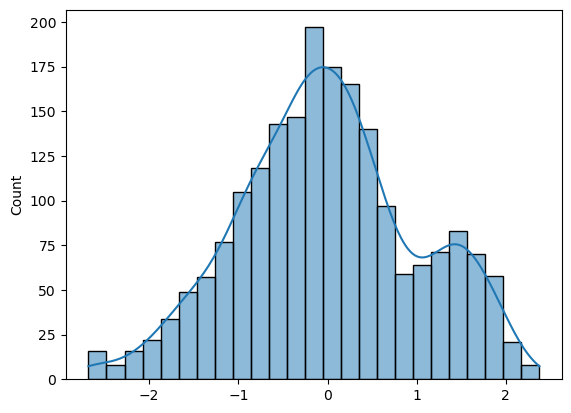

In [72]:
sns.histplot(y_trans, kde=True)

### THE PLOTS TO IDENTIFY THE Properties of the output columns

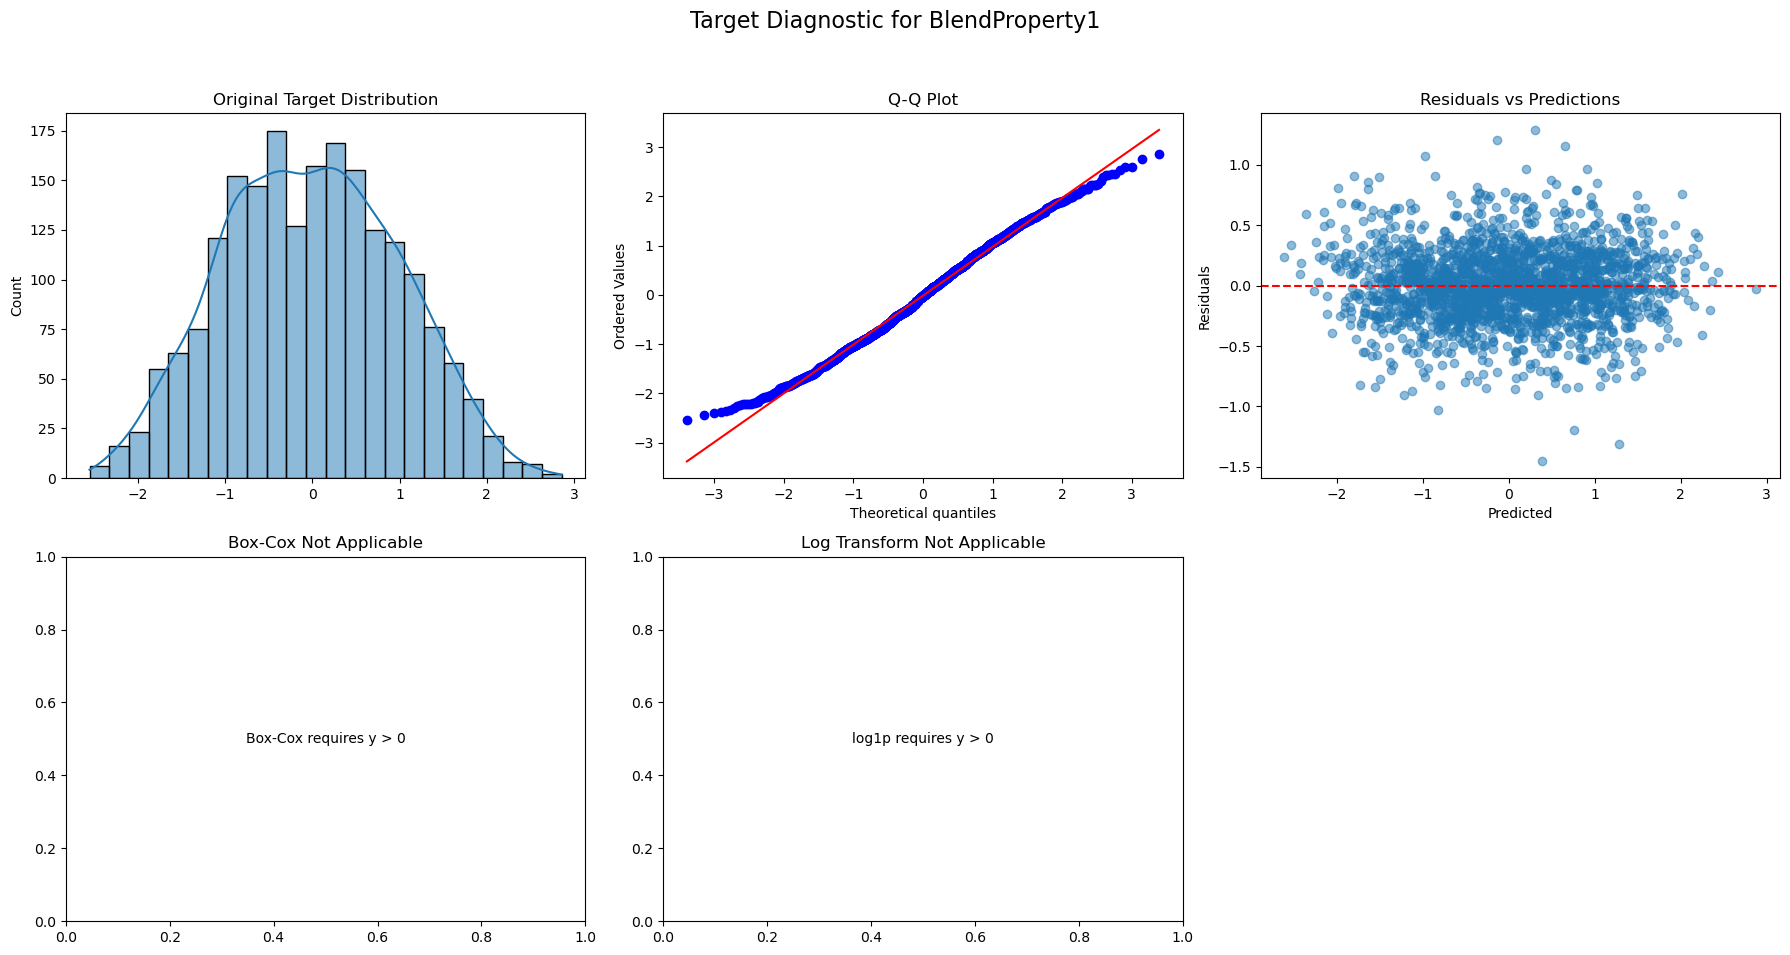

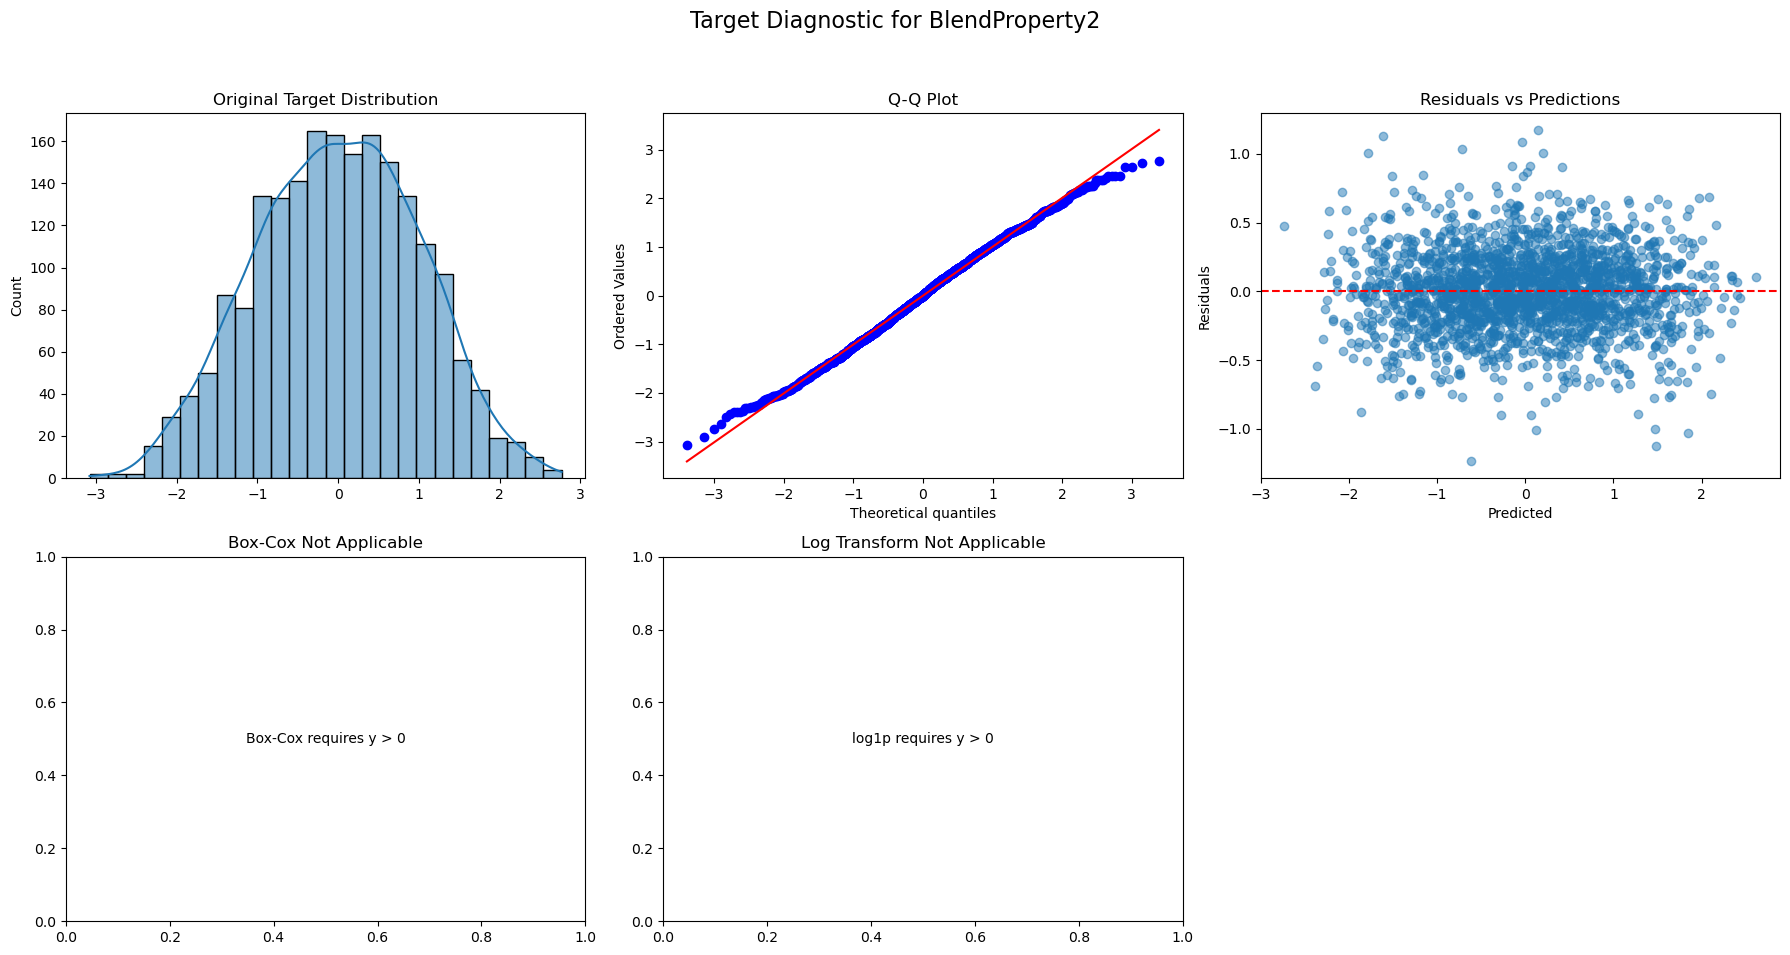

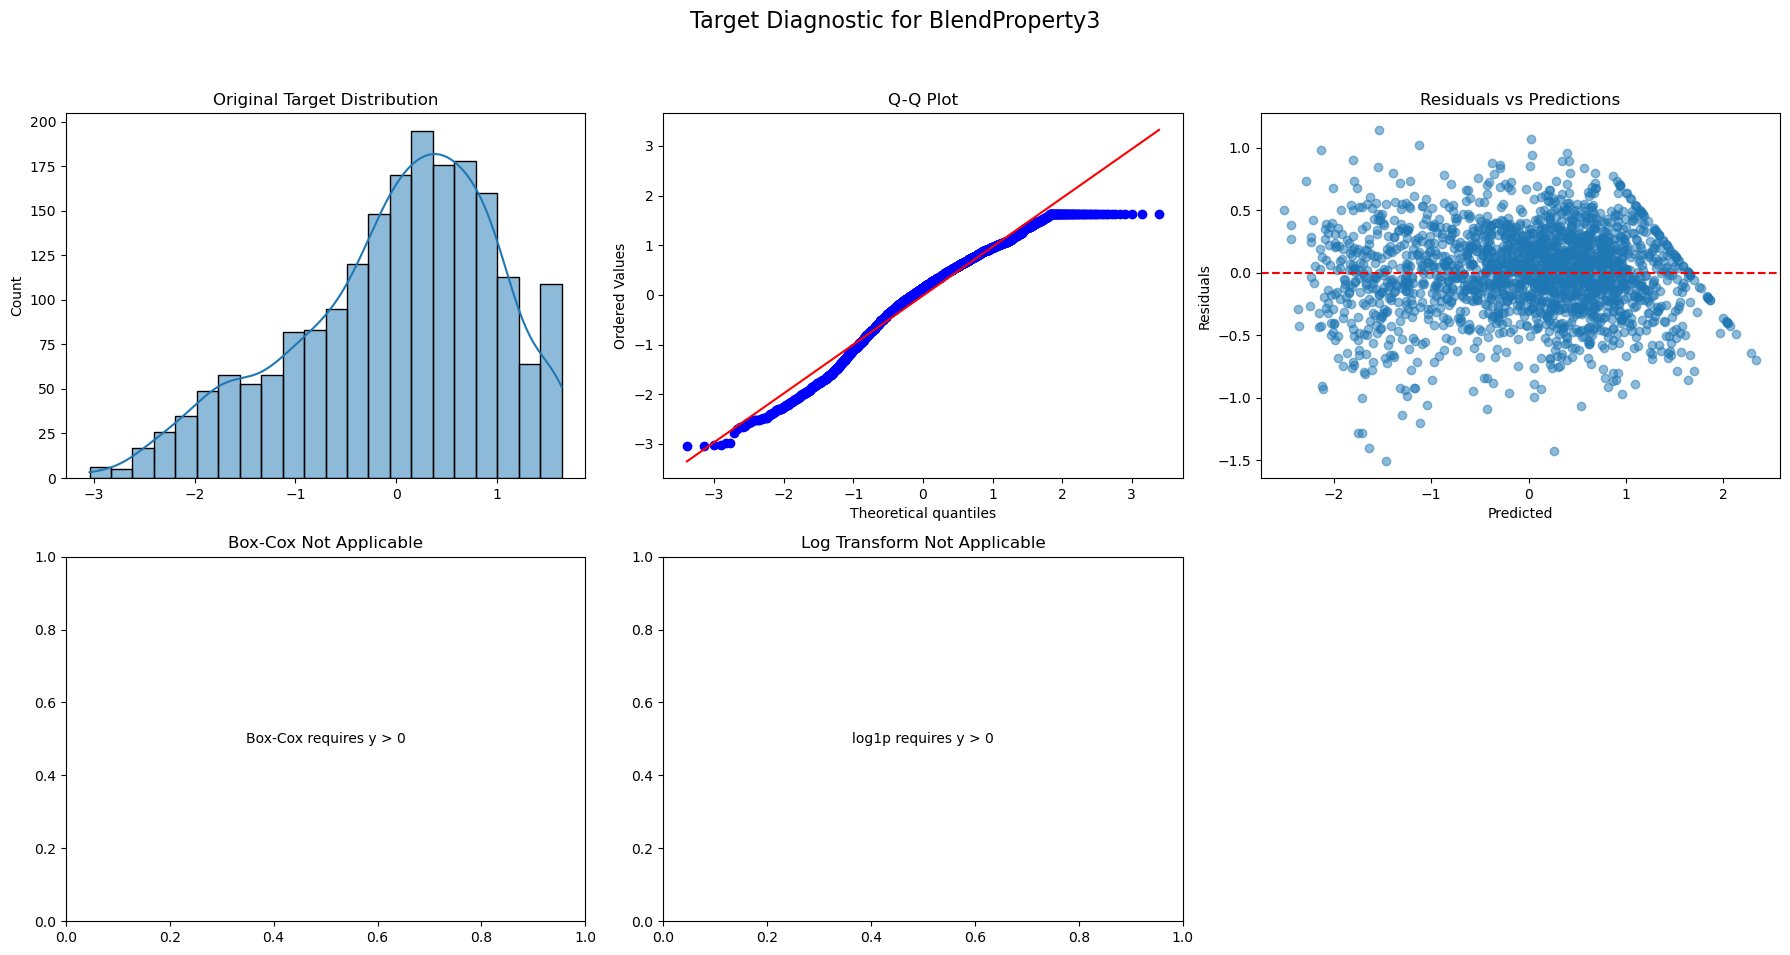

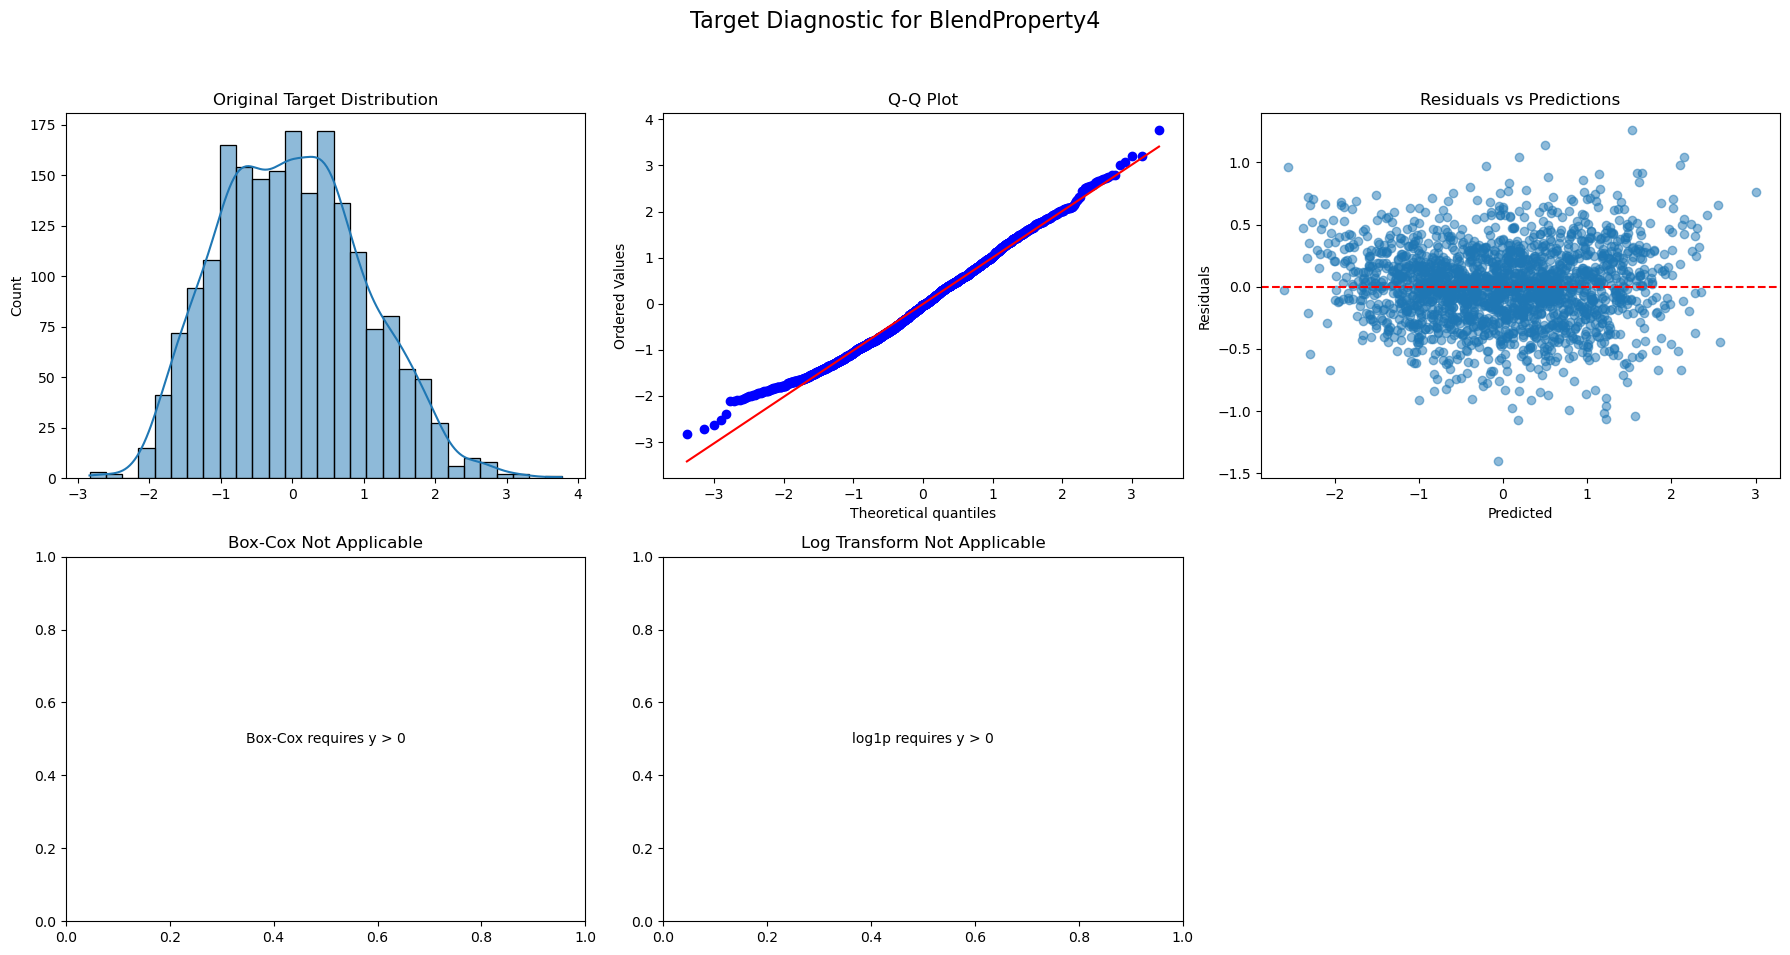

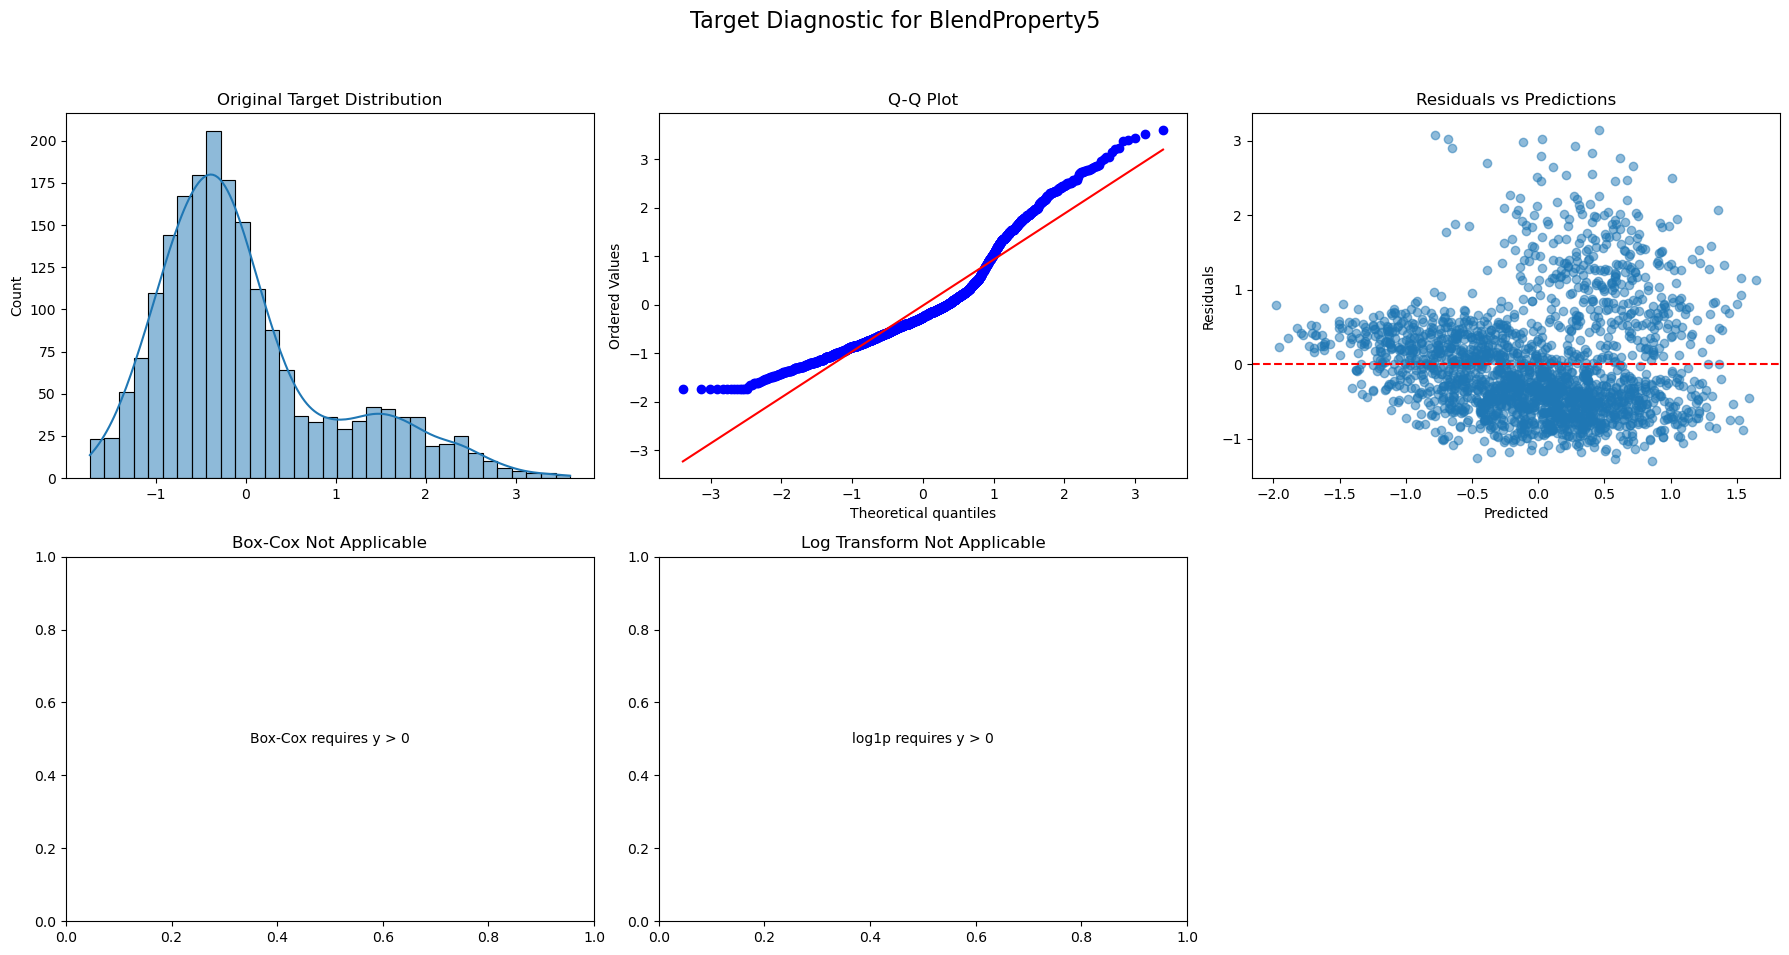

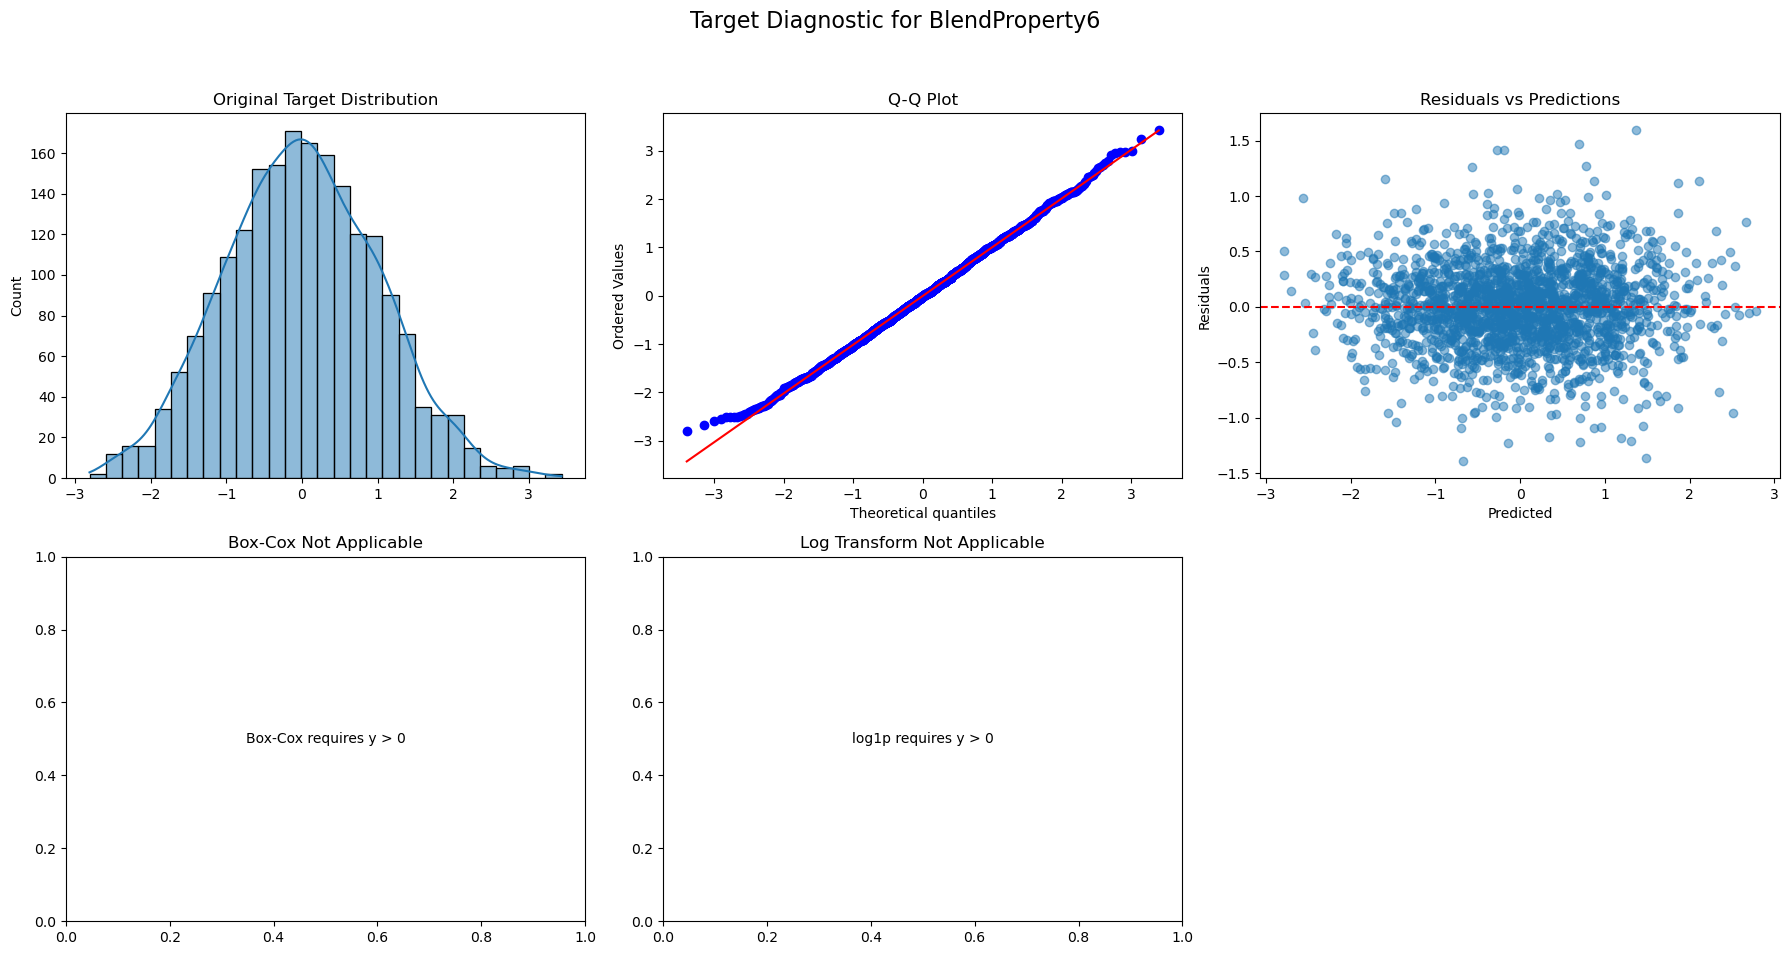

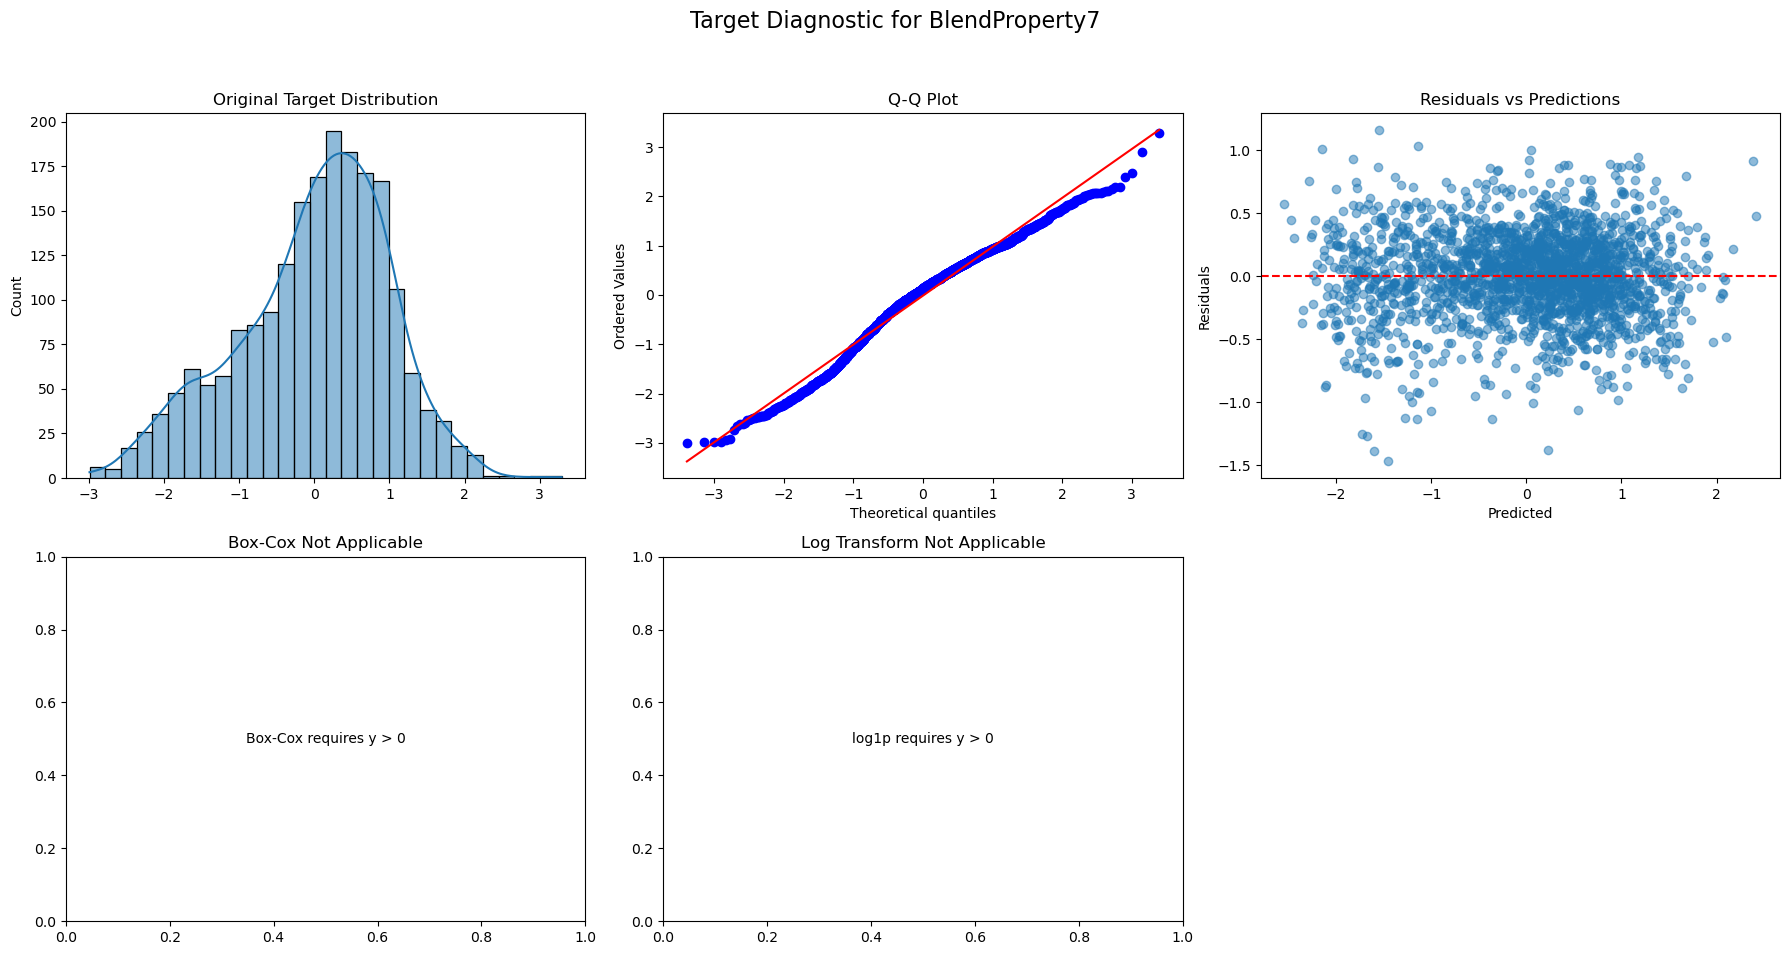

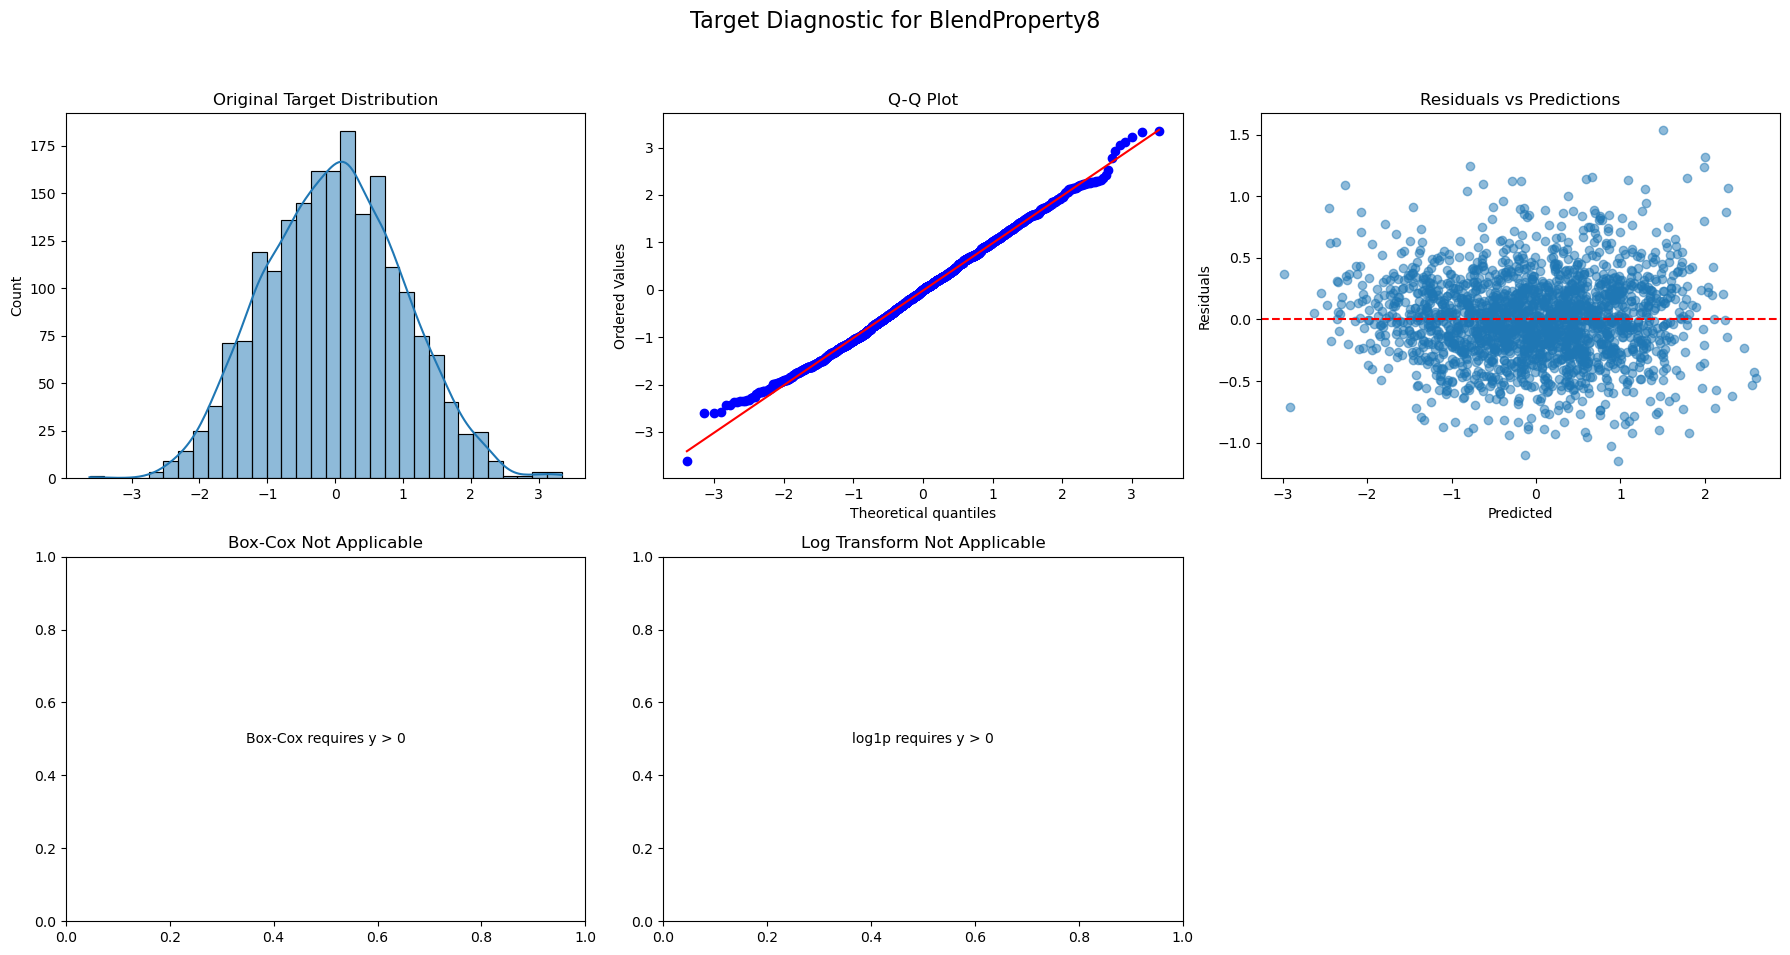

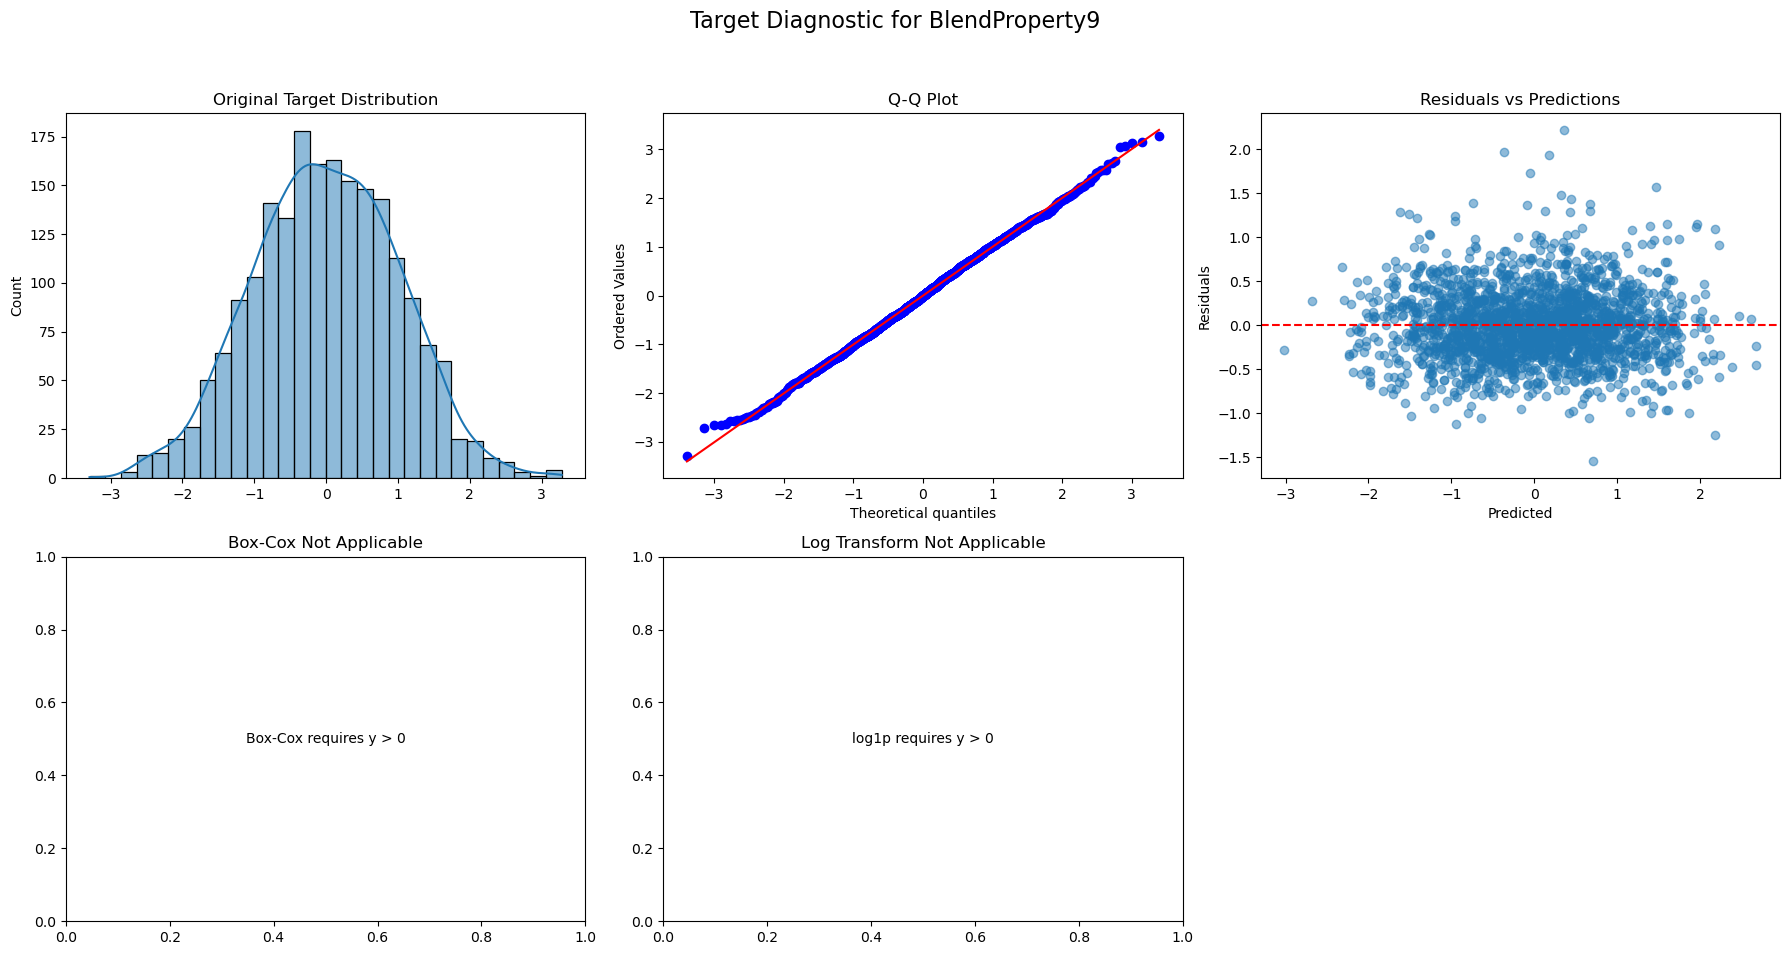

In [7]:
# Assume train_df already exists and contains columns BlendProperty0 to BlendProperty9
X = train_df.drop([f'BlendProperty{i}' for i in range(1,11)], axis=1).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

for i in range(1,10):
    y = train_df[[f'BlendProperty{i}']].values.ravel()
    
    fig, axs = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f"Target Diagnostic for BlendProperty{i}", fontsize=16)

    # 1. Histogram + KDE
    sns.histplot(y, kde=True, ax=axs[0, 0])
    axs[0, 0].set_title("Original Target Distribution")

    # 2. Q-Q plot
    stats.probplot(y, dist="norm", plot=axs[0, 1])
    axs[0, 1].set_title("Q-Q Plot")

    # 3. Residual plot from linear model
    model = LinearRegression().fit(X_scaled, y)
    y_pred = model.predict(X_scaled)
    residuals = y - y_pred
    axs[0, 2].scatter(y_pred, residuals, alpha=0.5)
    axs[0, 2].axhline(0, color='red', linestyle='--')
    axs[0, 2].set_title("Residuals vs Predictions")
    axs[0, 2].set_xlabel("Predicted")
    axs[0, 2].set_ylabel("Residuals")

    # 4. Box-Cox λ value (only if y > 0)
    if np.all(y > 0):
        y_boxcox, lmbda = stats.boxcox(y)
        sns.histplot(y_boxcox, kde=True, ax=axs[1, 0])
        axs[1, 0].set_title(f"Box-Cox Transformed (λ={lmbda:.2f})")
    else:
        axs[1, 0].text(0.5, 0.5, 'Box-Cox requires y > 0', ha='center', va='center')
        axs[1, 0].set_title("Box-Cox Not Applicable")

    # 5. Log-transform plot (if y > 0)
    if np.all(y > 0):
        y_log = np.log1p(y)
        sns.histplot(y_log, kde=True, ax=axs[1, 1])
        axs[1, 1].set_title("Log(1 + y) Transformed Distribution")
    else:
        axs[1, 1].text(0.5, 0.5, 'log1p requires y > 0', ha='center', va='center')
        axs[1, 1].set_title("Log Transform Not Applicable")

    # 6. Leave last plot blank or add any extra insight
    axs[1, 2].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

### Feature Engineering

In [448]:
from itertools import combinations
def create_blend_features(df, is_train=True, target_cols=None):
    """
    Generate engineered features for blending property prediction.

    Parameters:
    - df (pd.DataFrame): Input DataFrame with component fractions and properties.
    - is_train (bool): Set to True if training data (i.e., includes target columns).
    - target_cols (list): Required if is_train=True. List of target column names (BlendProperty1–10).

    Returns:
    - features_df (pd.DataFrame): Final feature matrix including original and engineered features.
    - target_df (pd.DataFrame, optional): If training data, returns the target DataFrame.
    """

    print(f"🔧 Creating features for {len(df)} samples...")

    # ========== SETUP ==========
    num_components = 5
    num_properties = 10

    fraction_cols = [f'Component{i}_fraction' for i in range(1, num_components + 1)]
    fraction_array = df[fraction_cols].values

    # Reshape all component properties to (samples, components, properties)
    component_props = []
    for i in range(1, num_components + 1):
        prop_cols = [f'Component{i}_Property{j}' for j in range(1, num_properties + 1)]
        component_props.append(df[prop_cols].values)
    component_props = np.stack(component_props, axis=1)  # shape: (N, 5, 10)

    # Start with fractions as base features
    features_df = df[fraction_cols].copy()

    # ========== LINEAR + STATISTICAL BLEND FEATURES ==========
    print("⚙️ Creating linear baseline and statistical features...")

    weighted_avg = (fraction_array[:, :, np.newaxis] * component_props).sum(axis=1)
    blend_max = component_props.max(axis=1)
    blend_min = component_props.min(axis=1)
    blend_std = component_props.std(axis=1)
    blend_range = blend_max - blend_min

    blend_feats = np.concatenate([weighted_avg, blend_max, blend_min, blend_std, blend_range], axis=1)
    blend_feat_names = (
        [f'blend_weighted_avg_p{j}' for j in range(1, 11)] +
        [f'blend_max_p{j}' for j in range(1, 11)] +
        [f'blend_min_p{j}' for j in range(1, 11)] +
        [f'blend_std_p{j}' for j in range(1, 11)] +
        [f'blend_range_p{j}' for j in range(1, 11)]
    )
    blend_feat_df = pd.DataFrame(blend_feats, columns=blend_feat_names, index=df.index)
    features_df = pd.concat([features_df, blend_feat_df], axis=1)

    # ========== FRACTION INTERACTION FEATURES ==========
    print("🔗 Adding pairwise fraction interaction features...")
    for i, j in combinations(range(num_components), 2):
        col_name = f'frac_interaction_{i+1}x{j+1}'
        features_df[col_name] = fraction_array[:, i] * fraction_array[:, j]

    # ========== ADVANCED PROPERTY INTERACTIONS ==========
    print("💥 Adding advanced property-difference interaction features...")
    for i, k in combinations(range(num_components), 2):
        frac_product = fraction_array[:, i] * fraction_array[:, k]
        for j in range(num_properties):
            prop_diff_sq = (component_props[:, i, j] - component_props[:, k, j]) ** 2
            col_name = f'prop_interaction_{i+1}x{k+1}_p{j+1}'
            features_df[col_name] = frac_product * prop_diff_sq

    # ========== ORIGINAL STYLE SKEWNESS FEATURES ==========
    print("✨ Retaining unique original interaction features...")
    for j in range(num_properties):
        features_df[f'diff_max_avg_p{j+1}'] = blend_max[:, j] - weighted_avg[:, j]
        features_df[f'diff_avg_min_p{j+1}'] = weighted_avg[:, j] - blend_min[:, j]

    # ========== CLEAN-UP ==========
    print("🧼 Optimizing data types...")
    features_df.replace([np.inf, -np.inf], 0, inplace=True)
    for col in features_df.columns:
        features_df[col] = features_df[col].astype(np.float32)

    print(f"✅ Done! Extracted {features_df.shape[1]} features.")

    if is_train:
        if target_cols is None:
            raise ValueError("`target_cols` must be provided when `is_train=True`.")
        target_df = df[target_cols].copy().astype(np.float32)
        return features_df, target_df
    else:
        return features_df

##### Feature engineered dataset

In [449]:
# Your blend property targets
target_cols = [f'BlendProperty{i}' for i in range(1, 11)]

In [450]:
# Training data
X_train_fe, y_train_fe = create_blend_features(train_df, is_train=True, target_cols=target_cols)
# Test data (no targets present)
X_test_fe = create_blend_features(test_df, is_train=False)
X_train_fe.columns==X_test_fe.columns

🔧 Creating features for 2000 samples...
⚙️ Creating linear baseline and statistical features...
🔗 Adding pairwise fraction interaction features...
💥 Adding advanced property-difference interaction features...
✨ Retaining unique original interaction features...
🧼 Optimizing data types...


C:\Users\Hemant Pathak\AppData\Local\Temp\ipykernel_19292\3422225980.py:68: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features_df[col_name] = frac_product * prop_diff_sq
C:\Users\Hemant Pathak\AppData\Local\Temp\ipykernel_19292\3422225980.py:68: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  features_df[col_name] = frac_product * prop_diff_sq
C:\Users\Hemant Pathak\AppData\Local\Temp\ipykernel_19292\3422225980.py:68: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many

✅ Done! Extracted 185 features.
🔧 Creating features for 500 samples...
⚙️ Creating linear baseline and statistical features...
🔗 Adding pairwise fraction interaction features...
💥 Adding advanced property-difference interaction features...
✨ Retaining unique original interaction features...
🧼 Optimizing data types...
✅ Done! Extracted 185 features.


array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

##### Combining the Component properties columns with the feature engineered dataset

In [437]:
# X_Train_combined=pd.concat([X_train_fe,train_df.iloc[:,5:59]], axis=1)
# X_Test_combined=pd.concat([X_test_fe, test_df.iloc[:,1:55]], axis=1)
# X_Train_combined.shape, y_train_fe.shape, X_Test_combined.shape

In [452]:
# X_Test_combined.columns==X_Train_combined.columns
# test_df.head()
X_train_fe.shape==X_test_fe.shape

False

<!-- ### Training catboost with MultiOutputRegresssor -->

In [453]:
# Perform 85% train / 15% validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_train_fe, y_train_fe, test_size=0.15, random_state=42, shuffle=True
)
X_train.shape, X_val.shape, y_train.shape, y_val.shape


((1700, 185), (300, 185), (1700, 10), (300, 10))

### Catboost

In [454]:
# Define CatBoost parameters
catboost_params = {
    'iterations': 100,
    'learning_rate': 0.03,
    'depth': 6,
    'loss_function': 'MAPE',
    'eval_metric': 'MAPE',
    'verbose': 1,
    'random_seed': 42,
}

# Initialize base CatBoost model
base_model = CatBoostRegressor(**catboost_params)

# Wrap it in MultiOutputRegressor
model = MultiOutputRegressor(base_model)

# Fit the multi-output model
model.fit(X_train, y_train)

# Predict on validation or test set
val_preds = model.predict(X_val)
test_preds = model.predict(X_test_fe)  # If you want predictions on test set

0:	learn: 0.6470314	total: 67.9ms	remaining: 6.72s
1:	learn: 0.6340762	total: 95.8ms	remaining: 4.7s
2:	learn: 0.6236019	total: 112ms	remaining: 3.63s
3:	learn: 0.6110286	total: 128ms	remaining: 3.08s
4:	learn: 0.5984300	total: 144ms	remaining: 2.74s
5:	learn: 0.5874357	total: 159ms	remaining: 2.49s
6:	learn: 0.5757782	total: 174ms	remaining: 2.31s
7:	learn: 0.5659948	total: 190ms	remaining: 2.18s
8:	learn: 0.5562776	total: 206ms	remaining: 2.08s
9:	learn: 0.5447990	total: 221ms	remaining: 1.99s
10:	learn: 0.5331371	total: 238ms	remaining: 1.93s
11:	learn: 0.5238775	total: 254ms	remaining: 1.86s
12:	learn: 0.5138687	total: 270ms	remaining: 1.81s
13:	learn: 0.5057803	total: 287ms	remaining: 1.76s
14:	learn: 0.4957581	total: 305ms	remaining: 1.73s
15:	learn: 0.4871008	total: 321ms	remaining: 1.69s
16:	learn: 0.4770301	total: 337ms	remaining: 1.65s
17:	learn: 0.4684983	total: 353ms	remaining: 1.61s
18:	learn: 0.4605358	total: 369ms	remaining: 1.57s
19:	learn: 0.4533847	total: 384ms	remain

In [456]:
# Initialize lists to store metrics
mape_scores = []
r2_scores = []
mae_scores = []

# Calculate metrics for each target column
for i, col in enumerate(y_val.columns):
    y_true = y_val.iloc[:, i]
    y_pred = val_preds[:, i]
    
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    
    mape_scores.append(mape)
    r2_scores.append(r2)
    mae_scores.append(mae)

# Combine into a DataFrame for display
metrics_df = pd.DataFrame({
    'BlendProperty': y_val.columns,
    'MAPE': mape_scores,
    'R2': r2_scores,
    'MAE': mae_scores
})

print(metrics_df.to_string(index=False))

  BlendProperty      MAPE       R2      MAE
 BlendProperty1 32.682263 0.903307 0.232127
 BlendProperty2  1.815581 0.898140 0.233668
 BlendProperty3  1.990414 0.841358 0.307946
 BlendProperty4  0.962025 0.908220 0.219542
 BlendProperty5  1.852733 0.755373 0.409182
 BlendProperty6  1.004349 0.928208 0.194264
 BlendProperty7  1.357642 0.834286 0.312241
 BlendProperty8  2.451752 0.840374 0.301562
 BlendProperty9  2.533165 0.659291 0.475436
BlendProperty10  0.882252 0.910607 0.229994


In [466]:
test_preds = model.predict(X_test_fe)  # If you want predictions on test set

# Assuming test_preds is a NumPy array of shape (n_samples, 10)
test_df_sub = pd.DataFrame(test_preds, columns=[f"BlendProperty{i+1}" for i in range(test_preds.shape[1])])

# Insert ID column at the beginning (1-based indexing)
test_df_sub.insert(0, 'ID', np.arange(1, len(test_df) + 1))

# Display the resulting DataFrame
print(test_df_sub.head())
test_df_sub.head()
test_df_sub.to_csv('Feature_engineered_Catboost_2_new.csv', index=False)

   ID  BlendProperty1  BlendProperty2  BlendProperty3  BlendProperty4  \
0   1       -0.133909        0.260951        0.418017        0.612671   
1   2       -0.473349       -0.160555       -0.986065        0.074076   
2   3        1.270646        0.943573        0.761139        0.814451   
3   4       -0.096622        0.550981        0.581931       -0.212739   
4   5        0.174798       -0.631749        0.952076        0.326172   

   BlendProperty5  BlendProperty6  BlendProperty7  BlendProperty8  \
0       -0.294287        0.740540        0.327906        0.460868   
1       -0.656023        0.103840       -0.926618       -0.729388   
2        1.722044        1.418248        0.794053        1.449004   
3        1.488590       -0.348765        0.512818        1.063940   
4        1.474394       -0.188362        0.932563       -0.404792   

   BlendProperty9  BlendProperty10  
0       -0.131382        -0.013818  
1       -0.107208         0.087433  
2        0.543958         1.670055 

C:\Users\Hemant Pathak\AppData\Local\Temp\ipykernel_19292\3303063779.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='importance', y='feature', ax=axes[i-1], palette="viridis")
C:\Users\Hemant Pathak\AppData\Local\Temp\ipykernel_19292\3303063779.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='importance', y='feature', ax=axes[i-1], palette="viridis")
C:\Users\Hemant Pathak\AppData\Local\Temp\ipykernel_19292\3303063779.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='importance', y='feature', a

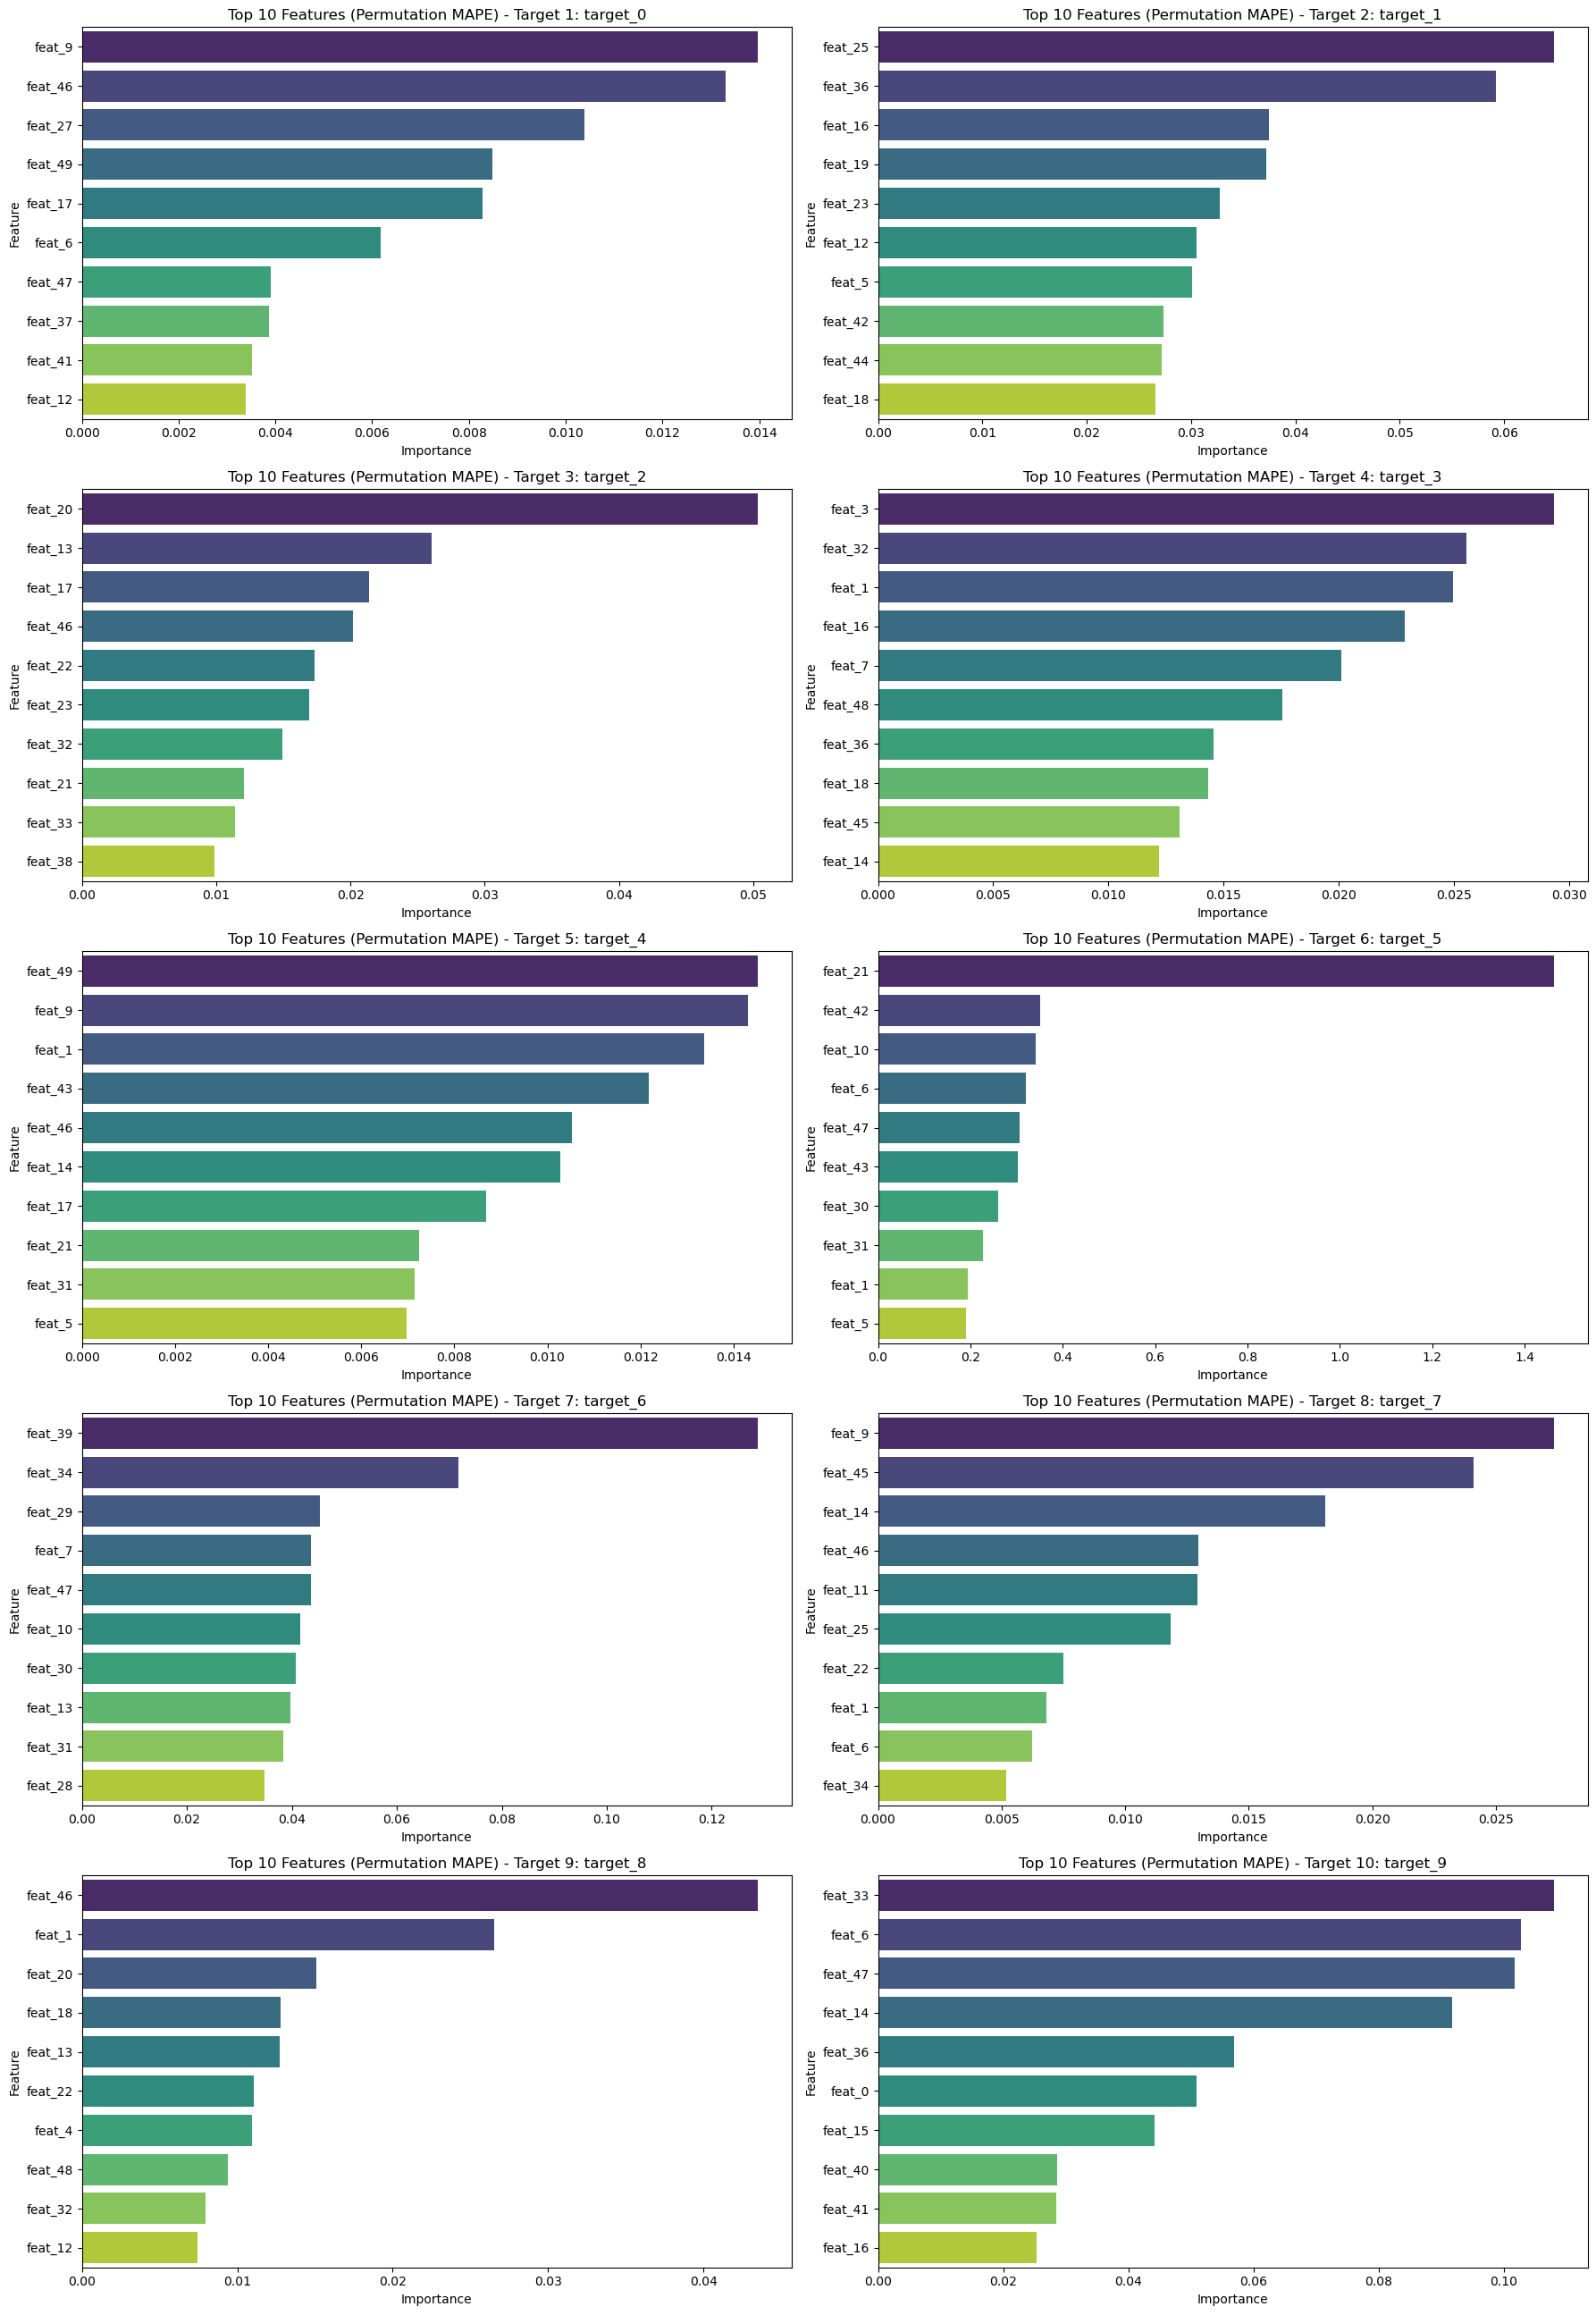

In [362]:
# Simulate the original setup using real column names and 1-based target name

# Simulate trained_models with dummy regressors and permutation importance values
# (can't use CatBoost in this environment)
from sklearn.ensemble import RandomForestRegressor
trained_models = {}
perm_importances_all = {}

for i, target_col in enumerate(y_train.columns):
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train[target_col])
    trained_models[target_col] = model

    result = permutation_importance(
        model, X_val, y_val[target_col],
        scoring='neg_mean_absolute_percentage_error',
        n_repeats=5,
        random_state=42
    )

    importance_df = pd.DataFrame({
        'feature': X_train.columns,
        'importance': result.importances_mean
    }).sort_values(by='importance', ascending=False).head(10)

    perm_importances_all[target_col] = importance_df

# Plotting with 1-based indexing in titles
fig, axes = plt.subplots(5, 2, figsize=(18, 26))
axes = axes.flatten()

for i, (target_name, df) in enumerate(perm_importances_all.items(), start=1):
    sns.barplot(data=df, x='importance', y='feature', ax=axes[i-1], palette="viridis")
    axes[i-1].set_title(f"Top 10 Features (Permutation MAPE) - Target {i}: {target_name}")
    axes[i-1].set_xlabel("Importance")
    axes[i-1].set_ylabel("Feature")

plt.tight_layout()
plt.show()


### MAPE INCREMENT

In [352]:
for col in y_train.columns:
    print(col, (y_train[col] < 0.05).sum(), 'values < 0.05')
for col in y_val.columns:
    print(col, (y_val[col] < 0.05).sum(), 'values < 0.05')

BlendProperty1 889 values < 0.05
BlendProperty2 879 values < 0.05
BlendProperty3 793 values < 0.05
BlendProperty4 913 values < 0.05
BlendProperty5 1122 values < 0.05
BlendProperty6 910 values < 0.05
BlendProperty7 801 values < 0.05
BlendProperty8 874 values < 0.05
BlendProperty9 883 values < 0.05
BlendProperty10 891 values < 0.05
BlendProperty1 162 values < 0.05
BlendProperty2 147 values < 0.05
BlendProperty3 131 values < 0.05
BlendProperty4 154 values < 0.05
BlendProperty5 187 values < 0.05
BlendProperty6 147 values < 0.05
BlendProperty7 135 values < 0.05
BlendProperty8 160 values < 0.05
BlendProperty9 157 values < 0.05
BlendProperty10 155 values < 0.05
